# Common Task 2 — Jets as Graphs: DGCNN (Pure PyTorch, No Installation)

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.neighbors import KDTree         
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
import warnings
warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'PyTorch: {torch.__version__}')

Device : cuda
GPU    : Tesla P100-PCIE-16GB
VRAM   : 17.1 GB
PyTorch: 2.9.0+cu126


In [2]:
HDF5_PATH    = '/kaggle/input/datasets/siddharthjaiswal23/data-task2/quark-gluon_data-set_n139306.hdf5'
N_SAMPLES    = 30000
K_NEIGHBOURS = 16 
MIN_POINTS   = 5  
THRESHOLD    = 1e-5 
HIDDEN_DIM   = 64   
LATENT_DIM   = 256  
BATCH_SIZE   = 32
LR           = 1e-3
EPOCHS       = 40
TRAIN_R      = 0.75
VAL_R        = 0.15
SAVE_PATH    = 'best_gnn.pth'
SEED         = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [4]:
def load_raw_to_ram(filepath, n_samples=30000, seed=42):
    rng = np.random.default_rng(seed)
    with h5py.File(filepath, 'r') as f:
        total  = f['X_jets'].shape[0]
        n      = min(n_samples, total)
        chosen = np.sort(rng.choice(total, size=n, replace=False))
        print(f'Loading {n:,} / {total:,} samples …')
        CHUNK  = 5000
        Xp, yp = [], []
        for start in range(0, n, CHUNK):
            batch = chosen[start:start+CHUNK].tolist()
            Xp.append(f['X_jets'][batch])
            yp.append(f['y'][batch])
            print(f'  {min(start+CHUNK, n):,}/{n:,}', end='\r')
    X = np.concatenate(Xp).astype(np.float32).transpose(0,3,1,2) 
    y = np.concatenate(yp).astype(np.int64)
    print(f'\nX: {X.shape}  y: {y.shape}')
    print(f'Gluon: {(y==0).sum():,}  Quark: {(y==1).sum():,}')
    return X, y
X_raw, y_all = load_raw_to_ram(HDF5_PATH, N_SAMPLES, SEED)

Loading 30,000 / 139,306 samples …
  30,000/30,000
X: (30000, 3, 125, 125)  y: (30000,)
Gluon: 15,168  Quark: 14,832


Sampling point cloud sizes from 2000 events
Mean: 664  Median: 641  Min: 215  Max: 1538


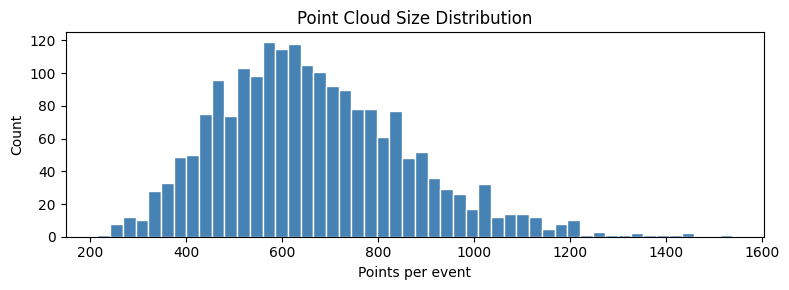

In [5]:
def image_to_point_cloud(img, threshold=1e-5):
    mask       = np.any(img > threshold, axis=0) 
    rows, cols = np.where(mask)
    if len(rows) < MIN_POINTS:
        return None
    eta = rows / 124.0
    phi = cols / 124.0
    def norm(v):
        v = np.log1p(v)
        vmax = v.max()
        return v / vmax if vmax > 0 else v
    ecal  = norm(img[0, rows, cols])
    hcal  = norm(img[1, rows, cols])
    track = norm(img[2, rows, cols])
    return np.stack([eta, phi, ecal, hcal, track], axis=1).astype(np.float32) 
print('Sampling point cloud sizes from 2000 events')
sizes = []
for i in range(2000):
    p = image_to_point_cloud(X_raw[i])
    if p is not None:
        sizes.append(len(p))
sizes = np.array(sizes)
print(f'Mean: {sizes.mean():.0f}  Median: {np.median(sizes):.0f}  '
      f'Min: {sizes.min()}  Max: {sizes.max()}')
plt.figure(figsize=(8,3))
plt.hist(sizes, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Points per event'); plt.ylabel('Count')
plt.title('Point Cloud Size Distribution')
plt.tight_layout(); plt.savefig('pc_sizes.png', dpi=100); plt.show()

In [10]:
def build_knn_graph(pts, k=16):
    pos  = pts[:, :2]          
    k    = min(k, len(pts) - 1)
    tree = KDTree(pos)
    _, idx = tree.query(pos, k=k+1)
    idx    = idx[:, 1:] 
    n    = len(pts)
    src  = idx.flatten() 
    dst  = np.repeat(np.arange(n), k) 
    src_all = np.concatenate([src, dst])
    dst_all = np.concatenate([dst, src])
    edges   = np.unique(np.stack([src_all, dst_all], axis=1), axis=0)
    return edges[:, 0].astype(np.int64), edges[:, 1].astype(np.int64) 
def build_all_graphs(X, y, k=16):
    graphs  = []
    skipped = 0
    n       = len(X)
    for i in range(n):
        pts = image_to_point_cloud(X[i])
        if pts is None:
            skipped += 1
            continue
        src, dst = build_knn_graph(pts, k=k)
        graphs.append({
            'x'  : torch.tensor(pts,              dtype=torch.float32),  
            'src': torch.tensor(src,              dtype=torch.long),     
            'dst': torch.tensor(dst,              dtype=torch.long),     
            'y'  : torch.tensor(int(y[i]),        dtype=torch.long),
        })
    g = graphs[0]
    print(f'Sample — nodes: {g["x"].shape[0]}  edges: {g["src"].shape[0]}  label: {g["y"].item()}')
    return graphs
all_graphs = build_all_graphs(X_raw, y_all, k=K_NEIGHBOURS)
import gc
del X_raw; gc.collect()
print('Raw images freed.')

Sample — nodes: 884  edges: 17480  label: 0
Raw images freed.


Quark Jet


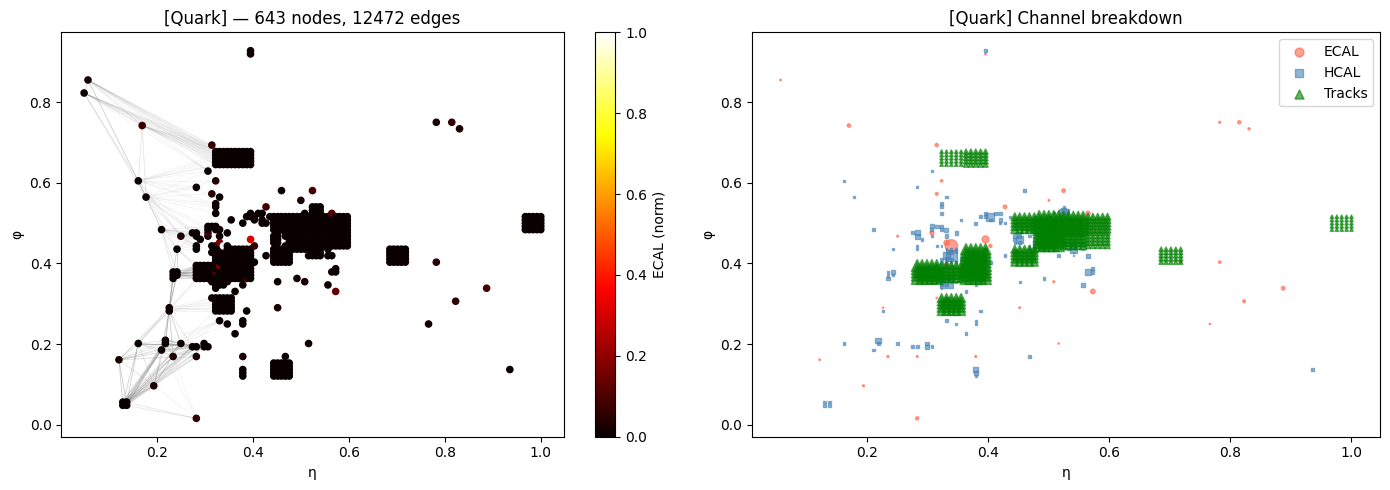

Gluon Jet


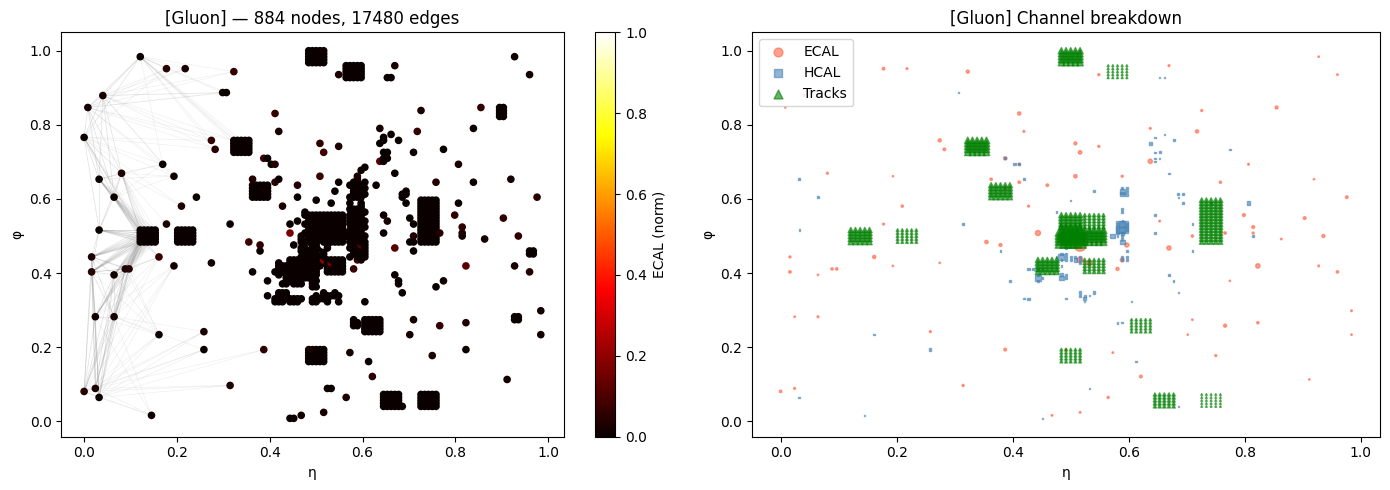

In [11]:
def visualize_jet_graph(graphs, idx=0):
    g      = graphs[idx]
    pos    = g['x'][:, :2].numpy()    
    x      = g['x'].numpy()           
    src    = g['src'].numpy()
    dst    = g['dst'].numpy()
    label  = 'Quark' if g['y'].item() == 1 else 'Gluon'
    energy = x[:, 2]                  
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax = axes[0]
    for e in range(min(len(src), 500)):   
        ax.plot([pos[src[e],0], pos[dst[e],0]],
                [pos[src[e],1], pos[dst[e],1]],
                color='grey', alpha=0.12, linewidth=0.5)
    sc = ax.scatter(pos[:,0], pos[:,1], c=energy, cmap='hot',
                    s=20, zorder=3, vmin=0, vmax=1)
    plt.colorbar(sc, ax=ax, label='ECAL (norm)')
    ax.set_xlabel('η'); ax.set_ylabel('φ')
    ax.set_title(f'[{label}] — {g["x"].shape[0]} nodes, {len(src)} edges')
    ax2 = axes[1]
    for c, (name, marker, color) in enumerate([
            ('ECAL', 'o', 'tomato'), ('HCAL', 's', 'steelblue'), ('Tracks', '^', 'green')]):
        mask = x[:, c+2] > 0.01
        if mask.sum() > 0:
            ax2.scatter(pos[mask,0], pos[mask,1],
                        s=x[mask,c+2]*80, alpha=0.6,
                        marker=marker, label=name, color=color)
    ax2.set_xlabel('η'); ax2.set_ylabel('φ')
    ax2.set_title(f'[{label}] Channel breakdown')
    ax2.legend()
    plt.tight_layout()
    plt.savefig(f'jet_graph_{label.lower()}.png', dpi=110)
    plt.show()
quark_idx = next(i for i,g in enumerate(all_graphs) if g['y'].item()==1)
gluon_idx = next(i for i,g in enumerate(all_graphs) if g['y'].item()==0)
print('Quark Jet')
visualize_jet_graph(all_graphs, quark_idx)
print('Gluon Jet')
visualize_jet_graph(all_graphs, gluon_idx)

In [12]:
class GraphDataset(Dataset):
    def __init__(self, graphs):
        self.graphs = graphs
    def __len__(self):
        return len(self.graphs)
    def __getitem__(self, idx):
        return self.graphs[idx]

def collate_graphs(batch):
    x_list, src_list, dst_list, batch_list, y_list = [], [], [], [], []
    node_offset = 0
    for i, g in enumerate(batch):
        n_nodes = g['x'].shape[0]
        x_list.append(g['x'])
        src_list.append(g['src'] + node_offset)   
        dst_list.append(g['dst'] + node_offset)
        batch_list.append(torch.full((n_nodes,), i, dtype=torch.long))
        y_list.append(g['y'])
        node_offset += n_nodes
    return {
        'x'    : torch.cat(x_list,     dim=0),
        'src'  : torch.cat(src_list,   dim=0),
        'dst'  : torch.cat(dst_list,   dim=0),
        'batch': torch.cat(batch_list, dim=0),
        'y'    : torch.stack(y_list,   dim=0),
    }

def split_and_load(graphs, train_r=0.75, val_r=0.15, batch_size=32, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(graphs))
    n       = len(graphs)
    n_train = int(n * train_r)
    n_val   = int(n * val_r)
    train = [graphs[i] for i in idx[:n_train]]
    val   = [graphs[i] for i in idx[n_train:n_train+n_val]]
    test  = [graphs[i] for i in idx[n_train+n_val:]]
    kw = dict(batch_size=batch_size, collate_fn=collate_graphs,
              num_workers=0, pin_memory=False)
    for name, split in [('train', train), ('val', val), ('test', test)]:
        nq = sum(g['y'].item() for g in split)
        print(f'{name:5s}: {len(split):,}  ({nq/len(split)*100:.1f}% quark)')
    return (DataLoader(GraphDataset(train), shuffle=True,  **kw),
            DataLoader(GraphDataset(val),   shuffle=False, **kw),
            DataLoader(GraphDataset(test),  shuffle=False, **kw))
train_loader, val_loader, test_loader = split_and_load(
    all_graphs, TRAIN_R, VAL_R, BATCH_SIZE, SEED
)

train: 22,500  (49.7% quark)
val  : 4,500  (48.9% quark)
test : 3,000  (48.3% quark)


In [13]:
def scatter_max_pool(src_feat, dst_idx, num_nodes):
    F_dim = src_feat.shape[1]
    out   = torch.full((num_nodes, F_dim), float('-inf'), device=src_feat.device)
    idx   = dst_idx.unsqueeze(1).expand(-1, F_dim) 
    out.scatter_reduce_(0, idx, src_feat, reduce='amax', include_self=True)
    out = torch.where(out == float('-inf'), torch.zeros_like(out), out)
    return out

def global_max_pool(x, batch, batch_size):
    F_dim = x.shape[1]
    out   = torch.full((batch_size, F_dim), float('-inf'), device=x.device)
    idx   = batch.unsqueeze(1).expand(-1, F_dim)
    out.scatter_reduce_(0, idx, x, reduce='amax', include_self=True)
    out   = torch.where(out == float('-inf'), torch.zeros_like(out), out)
    return out

def global_mean_pool(x, batch, batch_size):
    F_dim = x.shape[1]
    out   = torch.zeros(batch_size, F_dim, device=x.device)
    cnt   = torch.zeros(batch_size,        device=x.device)
    out.index_add_(0, batch, x)
    cnt.index_add_(0, batch, torch.ones(x.shape[0], device=x.device))
    return out / cnt.unsqueeze(1).clamp(min=1)

class EdgeConvLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(2 * in_dim, out_dim, bias=False),
            nn.BatchNorm1d(out_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(out_dim, out_dim, bias=False),
            nn.BatchNorm1d(out_dim),
            nn.LeakyReLU(0.2),
        )

    def forward(self, x, src, dst):
        x_src = x[src]         
        x_dst = x[dst]         
        edge_feat = self.mlp(torch.cat([x_dst, x_src - x_dst], dim=1)) 
        return scatter_max_pool(edge_feat, dst, num_nodes=x.shape[0])  


print('Core primitives defined (scatter_max, global_pool, EdgeConv).')

Core primitives defined (scatter_max, global_pool, EdgeConv).


In [14]:
class DGCNNClassifier(nn.Module):
    def __init__(self, in_dim=5, hidden=64, latent=256, num_classes=2):
        super().__init__()
        self.conv1 = EdgeConvLayer(in_dim,  hidden)          
        self.conv2 = EdgeConvLayer(hidden,  hidden * 2)      
        self.conv3 = EdgeConvLayer(hidden*2, latent)         
        self.head = nn.Sequential(
            nn.Linear(2 * latent, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256,        128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, batch_dict):
        x     = batch_dict['x'].to(DEVICE)
        src   = batch_dict['src'].to(DEVICE)
        dst   = batch_dict['dst'].to(DEVICE)
        batch = batch_dict['batch'].to(DEVICE)
        B     = batch_dict['y'].shape[0]      
        x = self.conv1(x, src, dst)           
        x = self.conv2(x, src, dst)           
        x = self.conv3(x, src, dst)           
        x_max  = global_max_pool (x, batch, B) 
        x_mean = global_mean_pool(x, batch, B) 
        x_g    = torch.cat([x_max, x_mean], dim=1)
        return self.head(x_g)                     

def build_model(in_dim=5, hidden=64, latent=256, lr=1e-3):
    model     = DGCNNClassifier(in_dim, hidden, latent).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
    n_params  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'DGCNNClassifier (pure PyTorch)')
    print(f'Trainable parameters: {n_params:,}')
    return model, criterion, optimizer, scheduler

model, criterion, optimizer, scheduler = build_model(
    in_dim=5, hidden=HIDDEN_DIM, latent=LATENT_DIM, lr=LR
)

DGCNNClassifier (pure PyTorch)
Trainable parameters: 334,850


In [15]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        y      = batch['y'].to(DEVICE)
        logits = model(batch)
        loss   = criterion(logits, y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * y.shape[0]
        correct    += (logits.argmax(1) == y).sum().item()
        total      += y.shape[0]
    return total_loss / total, correct / total

def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            y      = batch['y'].to(DEVICE)
            logits = model(batch)
            loss   = criterion(logits, y)
            probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            all_probs.append(probs)
            all_labels.append(y.cpu().numpy())
            total_loss += loss.item() * y.shape[0]
            correct    += (logits.argmax(1) == y).sum().item()
            total      += y.shape[0]
    probs  = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    auc    = roc_auc_score(labels, probs)
    return total_loss / total, correct / total, auc

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                epochs=40, save_path='best_gnn.pth', patience=8):
    history  = {'train_loss':[], 'val_loss':[], 'val_auc':[], 'val_acc':[]}
    best_auc = 0.0
    wait     = 0
    print(f'  {"Ep":>4}  {"TrainLoss":>10}  {"ValLoss":>9}  {"ValAUC":>8}  {"ValAcc":>7}')
    print('─' * 52)
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc              = train_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_auc   = evaluate(model, val_loader)
        scheduler.step()
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)
        history['val_acc'].append(val_acc)
        note = ''
        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(model.state_dict(), save_path)
            wait = 0
            note = ' best'
        else:
            wait += 1
        print(f'  {epoch:03d}/{epochs}  {tr_loss:10.4f}  {val_loss:9.4f}'
              f'  {val_auc:8.4f}  {val_acc*100:6.2f}%{note}')
        if wait >= patience:
            print(f'\nEarly stopping — Best Val AUC: {best_auc:.4f}')
            brea
    print(f'\nBest Val AUC: {best_auc:.4f}')
    return history
history = train_model(
    model, train_loader, val_loader,
    criterion, optimizer, scheduler,
    epochs=EPOCHS, save_path=SAVE_PATH
)

    Ep   TrainLoss    ValLoss    ValAUC   ValAcc
────────────────────────────────────────────────────
  001/40      0.6595     0.6094    0.7511   68.80% best
  002/40      0.6131     0.5920    0.7647   69.87% best
  003/40      0.5981     0.6072    0.7680   69.69% best
  004/40      0.5970     0.5916    0.7666   70.16%
  005/40      0.5955     0.5986    0.7688   70.07% best
  006/40      0.5917     0.5881    0.7717   71.13% best
  007/40      0.5896     0.5961    0.7755   71.53% best
  008/40      0.5899     0.5935    0.7740   70.73%
  009/40      0.5875     0.5776    0.7757   70.56% best
  010/40      0.5877     0.5770    0.7734   71.33%
  011/40      0.5839     0.5813    0.7783   71.67% best
  012/40      0.5813     0.5818    0.7784   71.38% best
  013/40      0.5789     0.5945    0.7776   71.56%
  014/40      0.5761     0.5794    0.7802   71.73% best
  015/40      0.5750     0.5880    0.7771   71.64%
  016/40      0.5739     0.5821    0.7791   71.49%
  017/40      0.5705     0.5832 

NameError: name 'brea' is not defined

In [16]:
def plot_training(history):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    ep = range(1, len(history['train_loss'])+1)
    axes[0].plot(ep, history['train_loss'], label='Train', linewidth=2)
    axes[0].plot(ep, history['val_loss'],   label='Val',   linewidth=2, linestyle='--')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy')
    axes[0].set_title('Loss Curves'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(ep, history['val_auc'], color='darkorange', linewidth=2, label='Val AUC')
    axes[1].axhline(0.5, color='grey', linestyle=':', label='Random')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('ROC-AUC')
    axes[1].set_title('Validation ROC-AUC'); axes[1].set_ylim(0.45, 1.0)
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('gnn_training.png', dpi=120)
    plt.show()
    print('Saved: gnn_training.png')
plot_training(history)

NameError: name 'history' is not defined

  DGCNN (EdgeConv) — Test Set Results
  ROC-AUC   : 0.7844
  Accuracy  : 70.63%


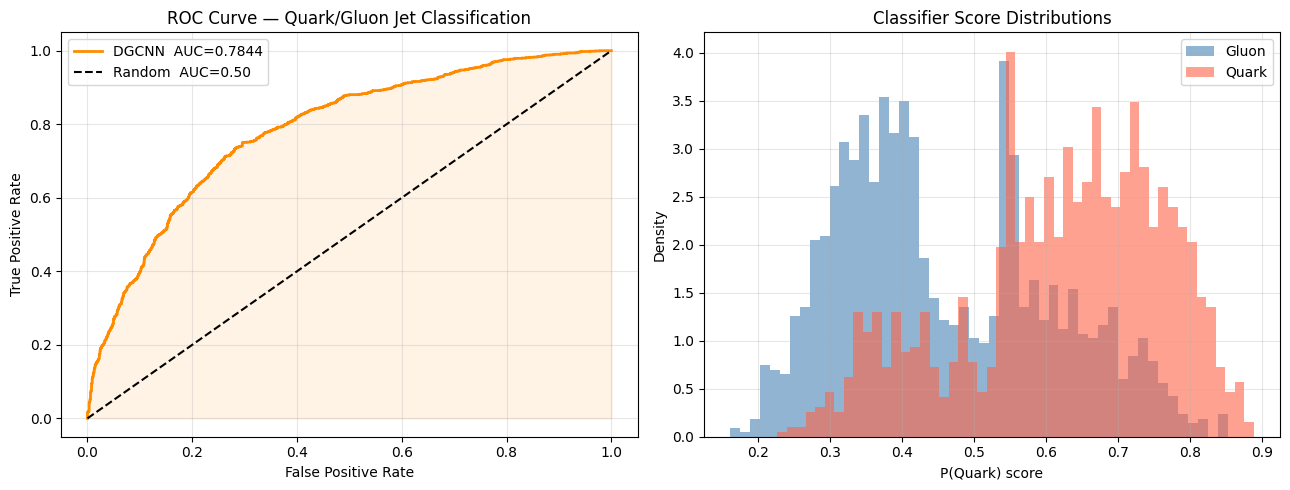

Saved: roc_curve.png


In [17]:
def full_evaluation(model, loader, save_path):
    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for batch in loader:
            y      = batch['y'].to(DEVICE)
            logits = model(batch)
            probs  = F.softmax(logits, dim=1)[:,1].cpu().numpy()
            preds  = logits.argmax(1).cpu().numpy()
            all_probs.append(probs)
            all_preds.append(preds)
            all_labels.append(y.cpu().numpy())
    probs  = np.concatenate(all_probs)
    preds  = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    auc = roc_auc_score(labels, probs)
    acc = accuracy_score(labels, preds)
    fpr, tpr, _ = roc_curve(labels, probs)
    print('  DGCNN (EdgeConv) — Test Set Results')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'  Accuracy  : {acc*100:.2f}%')
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'DGCNN  AUC={auc:.4f}')
    axes[0].plot([0,1],[0,1],'k--', label='Random  AUC=0.50')
    axes[0].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve — Quark/Gluon Jet Classification')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].hist(probs[labels==0], bins=50, alpha=0.6, density=True,
                 label='Gluon', color='steelblue')
    axes[1].hist(probs[labels==1], bins=50, alpha=0.6, density=True,
                 label='Quark', color='tomato')
    axes[1].set_xlabel('P(Quark) score')
    axes[1].set_ylabel('Density')
    axes[1].set_title('Classifier Score Distributions')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=120)
    plt.show()
    print('Saved: roc_curve.png')
    return auc, acc, probs, labels
auc, acc, probs, labels = full_evaluation(model, test_loader, SAVE_PATH)